#Import

In [1]:
!nvidia-smi

Mon Jan  3 09:51:51 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 495.44       Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla K80           Off  | 00000000:00:04.0 Off |                    0 |
| N/A   63C    P8    34W / 149W |      0MiB / 11441MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [2]:
#import torch
#data = torch.ones(1000,1000,1000,1000).cuda()

In [3]:
#!pip install torch==1.8.0 torchvision==0.9.0 torchaudio==0.8.0

In [4]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

import scipy.io as sio
from scipy.stats import zscore
import pandas as pd
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import models, transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F

import os
import shutil

from random import choice, sample, seed, randint, random, gauss
from scipy.io import loadmat
import skimage.morphology as skm
from torch.utils.data import ConcatDataset, DataLoader, Dataset
#from torchvision.datasets import DatasetFolder
import math
from google.colab import drive
from mpl_toolkits.axes_grid1 import ImageGrid
drive.mount('/content/drive')


#rendere l'esecuzione deterministica 
torch.manual_seed(0)
np.random.seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

1.10.0+cu111
True
Tesla K80
cuda:0
Mounted at /content/drive


# Uzip dati

In [5]:
!cp drive/My\ Drive/CampusBioMedico/VolumiDCE_EachLesion_Isotropic.zip  /content/
!unzip VolumiDCE_EachLesion_Isotropic.zip  -d /content/

Archive:  VolumiDCE_EachLesion_Isotropic.zip
   creating: /content/VolumiDCE_EachLesion_Isotropic/
   creating: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/
 extracting: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/100_Campolattano_a_1_18371.mat  
  inflating: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/103_Colatei_b_1_1245.mat  
  inflating: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/103_Colatei_b_2_5.mat  
 extracting: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/104_Consolino_a_1_3644.mat  
  inflating: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/104_Consolino_a_2_41.mat  
  inflating: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/105-106_Conti_a_1_1985.mat  
  inflating: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/105-106_Conti_b_1_1.mat  
  inflating: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/107_DAntono_a_1_808.mat  
  inflating: /content/VolumiDCE_EachLesion_Isotropic/0_cavo/108_DeFilippis_b_1_1801.mat  
 extracting: /content/VolumiDCE_EachLesion_Isotro

#Utility Function

In [6]:
#-------------------------------------------------------------------------------> Normalizzazione durante la lettura
def normalizeZscore(x, ax): #->ok
  #z score intra paziente
  #da usare quando non considero la maschera
  xz = zscore(x, axis=ax)
  return xz

def rangeNormalization(x, supLim, infLim): #->ok
  #normalizzazione nel range
  x_norm = ( (x - np.min(x)) / (np.max(x)- np.min(x)) )*(supLim - infLim) + infLim
  assert np.min(x_norm) >= infLim
  assert np.max(x_norm) <= supLim
  return x_norm

def np_imadjust(x, q1,q2): #->ok
  #applico un ehancement
  assert q1<q2
  assert q1+q2 == 1
  qq = np.quantile(x, [q1, q2])
  new = np.clip(x, qq[0], qq[1])
  return new

def multiply_mask(y, m): #->ok
  y_new = y*np.repeat(m[:,:,:,np.newaxis], 4, axis =3)
  return y_new

def convex_hull(mask): #->ok
  xx,yy,zz = np.where(mask>0)
  zz_u = np.unique(zz)
  new_mask = np.zeros(mask.shape)

  for i in zz_u:
    new_mask[:,:,i] = skm.convex_hull_image(mask[:,:,i]) 
  return new_mask

def complete_convex_hull(mask):
  new_mask = convex_hull(mask) #x y z
  new_mask = new_mask.transpose(2,0,1)   #z x y
  
  new_mask = convex_hull(new_mask)
  new_mask = new_mask.transpose(0,2,1)  #z y x
  
  new_mask = convex_hull(new_mask)
  new_mask = new_mask.transpose(2,1,0)
  return new_mask

def getFilesForSubset(basepath, list_classes, include_patient):
  ListFiles=[]
  for c in list_classes:
    listofFiles = os.listdir(basepath + '/' + c)
    for file in listofFiles:
      if include_patient(basepath + '/' + c + '/' + file):
        ListFiles.append((basepath + '/' + c + '/' + file, list_classes.index(c)))
  return ListFiles

def getListOffiles(basepath, list_classes, classe, include_patient):
  ListFiles=[]
  listofFiles = os.listdir(basepath + '/' + classe)
  for file in listofFiles:
    if include_patient(basepath + '/' + classe + '/' + file):
      ListFiles.append((basepath + '/' + classe + '/' + file, list_classes.index(classe)))
  return ListFiles, len(ListFiles)
  
class FocalLoss(nn.modules.loss._WeightedLoss):
  def __init__(self, weight=None, gamma=2,reduction='mean'):
    super(FocalLoss, self).__init__(weight,reduction=reduction)
    self.gamma = gamma
    self.weight = weight
    self.reduction = reduction

  def forward(self, input, target):
    ce_loss = F.cross_entropy(input, target,reduction='none',weight=self.weight)
    pt = torch.exp(-ce_loss)
    focal_loss = ((1 - pt) ** self.gamma * ce_loss)
    if self.reduction == 'mean':
      focal_loss = focal_loss.mean()
    else:
      focal_loss = focal_loss.sum()
    return focal_loss
  
#-------------------------------------------------------------------------------> Data Augmentation
class ToTensor3D(torch.nn.Module):  #-> ok
  def __init__(self):
    super().__init__()
  
  def forward(self, tensor):
    y_new = torch.from_numpy(tensor.transpose(3,2,0,1))
    return y_new

  def __repr__(self):
    return self.__class__.__name__ + '()'

class DeleteMask(torch.nn.Module):  #-> ok
  def __init__(self):
    super().__init__()
  
  def forward(self, tensor):
    return tensor

  def __repr__(self):
    return self.__class__.__name__ + '()'

class Resize3D(torch.nn.Module):  #-> ok
  def __init__(self, size=(32,32,32)):
    self.size = size          
    super().__init__()         

  def forward(self, tensor):
    #print(tensor.shape)
    #print(tensor.unsqueeze(0).shape)
    img = F.interpolate( tensor.unsqueeze(0), self.size, align_corners =True, mode='trilinear').squeeze(0)
    #print(img.shape)
    return img
    
  def __repr__(self):
    return self.__class__.__name__ + '(size={})'.format(self.size)

#-------------------------------------------------------------------------------> Data augmentation  forma C Z X Y
#------------------------------ Rotazione n*90
class Random_Rotation(torch.nn.Module):
  def __init__(self, p=0.5, n=1):
    self.p = p                        #probabilità di effettuare la rotazione
    self.n = n                        #numero di 90 gradi           
    super().__init__()         

  def forward(self, img):
    if random() < self.p:
      img = torch.rot90(img,self.n,dims=[2,3])
    return img
    
  def __repr__(self):
    return self.__class__.__name__ + '(p={}, n={})'.format(self.p, self.n)

#------------------------------ 
class RandomZFlip(torch.nn.Module):
  def __init__(self, p=0.5):
    self.p = p                        #probabilità di effettuare il flip  
    super().__init__()                 

  def forward(self, img):

    if random() < self.p:
      img = torch.flip(img, [1])
    return img
    
  def __repr__(self):
    return self.__class__.__name__ + '(p={})'.format(self.p)
        
#------------------------------ Media e std per channel
class Normalize(torch.nn.Module):
  def __init__(self, mean, std):
    self.mean = mean
    self.std = std
    super().__init__()
  
  def forward(self, tensor):  
    app =  tensor[0,:,:,:]
    new = ((app - self.mean[0]) /self.std[0]).unsqueeze(0)
    
    for i in range(1, tensor.shape[0]):
      app =  tensor[i,:,:,:]
      app = (app - self.mean[i]) /self.std[i]
      new = torch.cat([new, app.unsqueeze(0)], dim=0)
    return new
  
  def __repr__(self):
    return self.__class__.__name__ + '(mean={}, std={})'.format(self.mean, self.std )

#------------------------------ Media e std generica -->>ALL
class NormalizeOneMeanStd(torch.nn.Module):
  def __init__(self, mean, std):
    self.mean = mean
    self.std = std
    super().__init__()
    
  def forward(self, tensor):
    new = (tensor - self.mean.item())/self.std.item()  
    return new
    
  def __repr__(self):
    return self.__class__.__name__ + '(mean={}, std={})'.format(self.mean, self.std)
    
#------------------------------ Bilanciamento
class BalanceConcatDataset(ConcatDataset):  
    def __init__(self, datasets):
        # bilancia il numero di campioni nei vari dataset per replicazione
        l = max([len(dataset) for dataset in datasets])
        for dataset in datasets:
            while len(dataset) < l:
                dataset.samples += sample(dataset.samples, min(len(dataset), l - len(dataset)))
        super(BalanceConcatDataset, self).__init__(datasets)
              
#-------------------------------------> Media e STD  -> numpy
def np_computeMeanAndStd_all(train_files):  #-> generale
  channel_sum, channel_sqared_sum = 0.0,0.0
  num_batches = 0
  
  for f,l in train_files:
    data = readVolume(f)
    ss = np.array(data.shape)
    channel_sum += np.sum(data)
    channel_sqared_sum  += np.sum(data**2)
    num_batches += ss.prod()  #devo fare il prodotto delle dimensioni
  
  #print(num_batches)
  mean =channel_sum/num_batches
  std = (channel_sqared_sum/num_batches - mean**2)**0.5
  return mean, std


def np_computeMeanAndStd_channnel(train_files):
  channel_sum, channel_sqared_sum = 0.0,0.0
  num_batches = 0
  
  for f,l in train_files:
    data = readVolume(f)
    ss = np.array(data.shape)
    channel_sum += np.sum(data, axis=tuple(range(0,ss.shape[0]-1)))
    channel_sqared_sum  += np.sum(data**2, axis=tuple(range(0,ss.shape[0]-1)))
    num_batches += ss[:ss.shape[0]-1].prod()
  
  #print(num_batches)
  mean =channel_sum/num_batches
  std = (channel_sqared_sum/num_batches - mean**2)**0.5
  return mean, std
 
#-------------------------------------> Media e STD  -> torch
def torch_computeMeanAndStd_all(train_files): #-> generale
  channel_sum, channel_sqared_sum = 0.0,0.0
  num_batches = 0
  
  for f,l in train_files:
    data = readVolume(f)
    data = torch.from_numpy(data)
    ss = torch.tensor(data.shape)
    channel_sum += torch.sum(data)
    channel_sqared_sum  += torch.sum(data**2)
    num_batches += ss.prod()
  
  #print(num_batches)
  mean =channel_sum/num_batches
  std = (channel_sqared_sum/num_batches - mean**2)**0.5
  return mean, std
 
def torch_computeMeanAndStd_channnel(train_files):
  channel_sum, channel_sqared_sum = 0.0,0.0
  num_batches = 0
  
  for f,l in train_files:
    data = readVolume(f)
    data = torch.from_numpy(data)
    ss = torch.tensor(data.shape)
    channel_sum += torch.sum(data, dim=list(range(0, len(ss)-1)) )
    channel_sqared_sum  += torch.sum(data**2,  dim=list(range(0, len(ss)-1)))
    num_batches += ss[0:len(ss)-1].prod()
  
  #print(num_batches)
  mean =channel_sum/num_batches
  std = (channel_sqared_sum/num_batches - mean**2)**0.5
  return mean, std
    
##-------------------------------------------------------------------------------> Training functions
def train_loop_validation(model_conv, 
                          trainset, Val, test, 
                          start, num_epoch, 
                          loader_opts, 
                          criterionCNN, optimizer_conv, 
                          best_acc, best_loss, best_epoca,
                          outputPath):
  
  for epochs in range(start, num_epoch + 1):
    
    TrainLoader = DataLoader(trainset, shuffle=True, **loader_opts)
    
    modelLoss_train = 0.0
    modelAcc_train = 0.0
    totalSize = 0

    model_conv.train() 
    totPred = torch.empty(0)
    totLabels = torch.empty(0)

    #-----------------------------------------------------------------------------> TRAIN      
    for inputs, labels in TrainLoader:
      inputs = inputs.type(torch.FloatTensor).cuda()
      labels = labels.cuda()
      
      optimizer_conv.zero_grad()
      model_conv.zero_grad()
       
      y = model_conv(inputs)
      outp, preds = torch.max(y, 1)   
      lossCNN = criterionCNN(y, labels) #media per batch
       
      lossCNN.backward()
      optimizer_conv.step()
       
      totPred = torch.cat((totPred, preds.cpu()))
      totLabels = torch.cat((totLabels, labels.cpu()))
       
      modelLoss_train += lossCNN.item() * inputs.size(0)
      totalSize += inputs.size(0)
      modelAcc_train += torch.sum(preds == labels.data).item()
      
    
    modelLoss_epoch_train = modelLoss_train/totalSize
    modelAcc_epoch_train  = modelAcc_train/totalSize
    
    totPred = totPred.numpy()
    totLabels = totLabels.numpy()
    acc = np.sum((totPred == totLabels).astype(int))/totalSize
    
    x = totLabels[np.where(totLabels == 1)]
    y = totPred[np.where(totLabels == 1)]
    acc_1_T = np.sum((x == y).astype(int))/x.shape[0]
    
    x = totLabels[np.where(totLabels == 0)]
    y = totPred[np.where(totLabels == 0)]
    acc_0_T = np.sum((x == y).astype(int))/y.shape[0]
    
    with open(outputPath + 'lossTrain.txt', "a") as file_object:
      file_object.write(str(modelLoss_epoch_train) +'\n')
    with open(outputPath + 'AccTrain.txt', "a") as file_object:
      file_object.write(str(modelAcc_epoch_train)+'\n')
      
    torch.save(model_conv.state_dict(), outputPath + 'train_weights.pth')
      
    #-----------------------------------------------------------------------------> VALIDATION    

    model_conv.eval()

    totalSize_val = 0
    modelLoss_val = 0.0
    modelAcc_val = 0.0

    totPred_val = torch.empty(0)
    totLabels_val = torch.empty(0)
                    
    ValLoader = DataLoader(Val, shuffle=True, **loader_opts)
    for inputs, labels in ValLoader:
      inputs = inputs.type(torch.FloatTensor).cuda()
      labels = labels.cuda()

      y = model_conv(inputs)
      outp, preds = torch.max(y, 1)
      lossCNN = criterionCNN(y, labels)

      totPred_val = torch.cat((totPred_val, preds.cpu()))
      totLabels_val = torch.cat((totLabels_val, labels.cpu()))

      modelLoss_val += lossCNN.item() * inputs.size(0)  #Non pesata -> semplice media
      totalSize_val += inputs.size(0)
      modelAcc_val += torch.sum(preds == labels.data).item()
    
        
    modelLoss_epoch_val = modelLoss_val/totalSize_val
    modelAcc_epoch_val = modelAcc_val/totalSize_val

    totPred_val = totPred_val.numpy()
    totLabels_val = totLabels_val.numpy()
    acc_val = np.sum((totPred_val == totLabels_val).astype(int))/totalSize_val
    
    x = totLabels_val[np.where(totLabels_val == 1)]
    y = totPred_val[np.where(totLabels_val == 1)]
    acc_1_V = np.sum((x == y).astype(int))/x.shape[0]
    
    x = totLabels_val[np.where(totLabels_val == 0)]
    y = totPred_val[np.where(totLabels_val == 0)]
    acc_0_v = np.sum((x == y).astype(int))/y.shape[0]
    
      
    with open(outputPath + 'lossVal.txt', "a") as file_object:
      file_object.write(str(modelLoss_epoch_val) +'\n')
    
    with open(outputPath + 'AccVal.txt', "a") as file_object:
      file_object.write(str(modelAcc_epoch_val)+'\n')
    
    with open(outputPath + 'AccVal_0.txt', "a") as file_object:
      file_object.write(str(acc_0_v)+'\n')
      
    with open(outputPath + 'AccVal_1.txt', "a") as file_object:
      file_object.write(str(acc_1_V)+'\n')

    print('[Epoch %d][TRAIN on %d [Loss: %.4f - ACC_T: %.4f - ACC_0: %.4f - ACC_1: %.4f ]][VAL on %d [Loss: %.4f - ACC_T: %.4f - ACC_0: %.4f - ACC_1: %.4f]]' 
          %(epochs, totalSize, modelLoss_epoch_train, modelAcc_epoch_train, acc_0_T, acc_1_T,
            totalSize_val, modelLoss_epoch_val, 
            modelAcc_epoch_val, acc_0_v, acc_1_V))
    
    if epochs == 1 or (modelLoss_epoch_val <= best_loss) :
      
      print('     .... Saving best weights ....')
      best_acc = modelAcc_epoch_val
      best_loss = modelLoss_epoch_val
      best_epoca = epochs
      
      #salvataggio dei migliori pesi sul validation
      torch.save(model_conv.state_dict(), outputPath + 'best_model_weights.pth')

      #vedi il test come va
      tot_size_test = 0
      model_loss_test = 0.0
      modelAcc_acc_test = 0.0
      totPred_test = torch.empty(0)
      totLabels_test = torch.empty(0)  

      TestLoader = DataLoader(test, shuffle=True, **loader_opts)
      
      for  inputs, labels in TestLoader:
        inputs = inputs.type(torch.FloatTensor).cuda()
        labels = labels.cuda()
        
        y = model_conv(inputs)
        outp, preds = torch.max(y, 1)
        lossCNN = criterionCNN(y, labels)

        totPred_test = torch.cat((totPred_test, preds.cpu()))
        totLabels_test = torch.cat((totLabels_test, labels.cpu()))

        model_loss_test += lossCNN.item() * inputs.size(0)  #Non pesata -> semplice media
        tot_size_test += inputs.size(0)
        modelAcc_acc_test += torch.sum(preds == labels.data).item()
        
      modelLoss_epoch_test = model_loss_test/tot_size_test
      modelAcc_epoch_test = modelAcc_acc_test/tot_size_test
      
      totPred_test = totPred_test.numpy()
      totLabels_test = totLabels_test.numpy()
      acc_val = np.sum((totPred_test == totLabels_test).astype(int))/tot_size_test
      
      x = totLabels_test[np.where(totLabels_test == 1)]
      y = totPred_test[np.where(totLabels_test == 1)]
      acc_1_test = np.sum((x == y).astype(int))/x.shape[0]
      
      x = totLabels_test[np.where(totLabels_test == 0)]
      y = totPred_test[np.where(totLabels_test == 0)]
      acc_0_test = np.sum((x == y).astype(int))/y.shape[0]     
      

      print('      [TEST on %d [Loss: %.4f - ACC_T: %.4f - ACC_0: %.4f - ACC_1: %.4f ]]' 
            %(tot_size_test, modelLoss_epoch_test, modelAcc_epoch_test, acc_0_test, acc_1_test))

    
    sio.savemat(outputPath + 'check_point.mat', {'best_acc': best_acc, 
                                                 'best_loss': best_loss,
                                                 'best_epoca': best_epoca,
                                                 'last_epoch': epochs})   
  return model_conv


## #-------------------------------------------------------------------------------> Predict function
def prediction_on_Test(model_conv, test, transform):
  func = nn.Softmax(dim=1)
  predicted = pd.DataFrame()
  testFiles = test.samples

  for path, label_true in testFiles:
    inputs = readVolume(path)

    if transform is not None:
      inputs = transform(inputs)

    inputs = inputs.type(torch.FloatTensor).unsqueeze(0).cuda()
    
    parti = path.split('/')[-1].split('_')
    
    y = model_conv(inputs)
    outp, preds = torch.max(y, 1)
    y = func(y) 
    
    for i in range(0, inputs.shape[0]):
      predicted = predicted.append({'filename': path.split('/')[-1],
                                    'patient': parti[0]+'_'+parti[1],
                                    'patient_lato': parti[0]+'_'+parti[1]+'_'+parti[2],
                                    'dim_lesione': int(parti[4].split('.')[0]),
                                    'idx_lesione': int(parti[3]),
                                    'prob0': y[i,0].item(),
                                    'prob1': y[i,1].item(),
                                    'predicted': preds[i].item(),
                                    'true_class': label_true,
                                    }, ignore_index=True)
  return predicted
      
## #------------------------------------------------------------------------------->Retrain function
def train_loop(model_conv,
               trainset, test, 
               startEpoch, 
               num_epoch, loader_opts,
               criterionCNN, optimizer_conv, outputPath, 
               weightName, chekpointName):
  
  for epochs in range(startEpoch, num_epoch + 1):

    TrainLoader = DataLoader(trainset, shuffle=True, **loader_opts)
    modelLoss_train = 0.0
    modelAcc_train = 0.0
    totalSize = 0

    model_conv.train() 
    totPred = torch.empty(0)
    totLabels = torch.empty(0)
    #-----------------------------------------------------------------------------> TRAIN      
    for inputs, labels in TrainLoader:
      inputs = inputs.type(torch.FloatTensor).cuda()
      labels = labels.cuda()
    
      optimizer_conv.zero_grad()
      model_conv.zero_grad()
       
      y = model_conv(inputs)
      outp, preds = torch.max(y, 1)   
      lossCNN = criterionCNN(y, labels) #media per batch
       
      lossCNN.backward()
      optimizer_conv.step()
       
      totPred = torch.cat((totPred, preds.cpu()))
      totLabels = torch.cat((totLabels, labels.cpu()))
       
      modelLoss_train += lossCNN.item() * inputs.size(0)
      totalSize += inputs.size(0)
      modelAcc_train += torch.sum(preds == labels.data).item()
      
    modelLoss_epoch_train = modelLoss_train/totalSize
    modelAcc_epoch_train  = modelAcc_train/totalSize
    
    totPred = totPred.numpy()
    totLabels = totLabels.numpy()
    acc = np.sum((totPred == totLabels).astype(int))/totalSize
    
    x = totLabels[np.where(totLabels == 1)]
    y = totPred[np.where(totLabels == 1)]
    acc_1_T = np.sum((x == y).astype(int))/x.shape[0]
    
    x = totLabels[np.where(totLabels == 0)]
    y = totPred[np.where(totLabels == 0)]
    acc_0_T = np.sum((x == y).astype(int))/y.shape[0]

    torch.save(model_conv.state_dict(), outputPath + weightName)
    sio.savemat(outputPath + chekpointName, {'last_epoch': epochs}) 
      
    #-----------------------------------------------------------------------------> VALIDATION    
    model_conv.eval()
    tot_size_test = 0
    model_loss_test = 0.0
    modelAcc_acc_test = 0.0
    totPred_test = torch.empty(0)
    totLabels_test = torch.empty(0)  
    
    TestLoader = DataLoader(test, shuffle=True, **loader_opts)
    
    for  inputs, labels in TestLoader:
      inputs = inputs.type(torch.FloatTensor).cuda()
      labels = labels.cuda()

      y = model_conv(inputs)
      outp, preds = torch.max(y, 1)
      lossCNN = criterionCNN(y, labels)

      totPred_test = torch.cat((totPred_test, preds.cpu()))
      totLabels_test = torch.cat((totLabels_test, labels.cpu()))

      model_loss_test += lossCNN.item() * inputs.size(0)  #Non pesata -> semplice media
      tot_size_test += inputs.size(0)
      modelAcc_acc_test += torch.sum(preds == labels.data).item()
        
    modelLoss_epoch_test = model_loss_test/tot_size_test
    modelAcc_epoch_test = modelAcc_acc_test/tot_size_test

    totPred_test = totPred_test.numpy()
    totLabels_test = totLabels_test.numpy()
    acc_val = np.sum((totPred_test == totLabels_test).astype(int))/tot_size_test
      
    x = totLabels_test[np.where(totLabels_test == 1)]
    y = totPred_test[np.where(totLabels_test == 1)]
    acc_1_test = np.sum((x == y).astype(int))/x.shape[0]
      
    x = totLabels_test[np.where(totLabels_test == 0)]
    y = totPred_test[np.where(totLabels_test == 0)]
    acc_0_test = np.sum((x == y).astype(int))/y.shape[0] 

    
    print('[Epoch %d][TRAIN on %d [Loss: %.4f  ACC: %.4f - ACC_0: %.4f - ACC_1: %.4f]][TEST on %d [Loss: %.4f ][ACC_T: %.4f - ACC_0: %.4f - ACC_1: %.4f]]' 
          %(epochs, totalSize, modelLoss_epoch_train, modelAcc_epoch_train, acc_0_T, acc_1_T,
            tot_size_test, modelLoss_epoch_test, 
            modelAcc_epoch_test, acc_0_test, acc_1_test))
    
    
  return model_conv
  
#Definizione trasformazioni
def definisciTransf(meant, stdt, tipoNormalizzazione_str):
  print(tipoNormalizzazione_str)
  choice = transforms.RandomChoice([Random_Rotation(p=0.5, n=1),
                                    Random_Rotation(p=0.5, n=2), 
                                    Random_Rotation(p=0.5, n=3)])
  
  if tipoNormalizzazione_str == 'torch_computeMeanAndStd_all':
    NormFunction = NormalizeOneMeanStd(meant, stdt)
  elif tipoNormalizzazione_str == 'torch_computeMeanAndStd_channnel':
    NormFunction = Normalize(meant, stdt)
  else:
    NormFunction = DeleteMask()

  #----------------------------------------------------------------------------> CONTROLLO SULLA MASCHERA
  train_transform_0_cavo = transforms.Compose([ToTensor3D(),
                                               NormFunction,
                                               
                                               Resize3D(size=(64, 64, 64)),
                                               transforms.RandomHorizontalFlip(),
                                               transforms.RandomVerticalFlip(),
                                               RandomZFlip(),
                                               transforms.RandomRotation(degrees = 90),
                                               choice
                                               ])
  
  train_transform_1_cavo = transforms.Compose([ToTensor3D(),
                                               NormFunction,

                                               Resize3D(size=(64, 64, 64)),
                                               transforms.RandomHorizontalFlip(),
                                               transforms.RandomVerticalFlip(),
                                               RandomZFlip(),
                                               transforms.RandomRotation(degrees = 90),
                                               choice
                                               ])
  
  None_transform  = transforms.Compose([ToTensor3D(),
                                        NormFunction,
                                        Resize3D(size=(64, 64, 64))])

  return train_transform_0_cavo, train_transform_1_cavo, None_transform  

def statistiche(listFiles):
  mean_n_a, std_n_a = np_computeMeanAndStd_all(listFiles)
  print(mean_n_a)
  print(std_n_a)
  mean_n_c, std_n_c = np_computeMeanAndStd_channnel(listFiles)
  print(mean_n_c)
  print(std_n_c) 
  mean_t_a, std_t_a = torch_computeMeanAndStd_all(listFiles)
  print(mean_t_a)
  print(std_t_a)  
  mean_t_c, std_t_c = torch_computeMeanAndStd_channnel(listFiles)
  print(mean_t_c)
  print(std_t_c)

  return mean_t_a, std_t_a, mean_t_c, std_t_c                               

#Network Definition

In [7]:
#-------------------------------------------------------------------------------> Definizione della rete  
class ReductionCoreBlock(nn.Module):
  def __init__(self, inputChannel, outchannel, ksize, stride, pad):
    super(ReductionCoreBlock, self).__init__()

    self.downsample = nn.Sequential(
        nn.Conv3d(in_channels=inputChannel, out_channels=outchannel, kernel_size = ksize, stride = stride, padding=pad, bias=False),
        nn.BatchNorm3d(outchannel),
        nn.ReLU(inplace=True),
        )
  
  def forward(self, x):
    out = self.downsample(x)
    return out

#160 160 90
#Configurazione D -> potrebbe andare
class My3DNet(nn.Module):
  def __init__(self, nChannel, nfilters,printB):
    super(My3DNet, self).__init__()
    self.printB = printB
    self.reduction_1 =  nn.Sequential(
        ReductionCoreBlock(inputChannel = nChannel, outchannel=nfilters, ksize=(4,4,4), stride=(2,2,2), pad=(1,1,1)), 
    )

    self.reduction_2 = nn.Sequential(
        ReductionCoreBlock(inputChannel= nfilters, outchannel=nfilters*2, ksize=(4,4,4), stride=(2,2,2), pad=(1,1,1)), 
    )
    
    self.reduction_3 = nn.Sequential(
        ReductionCoreBlock(inputChannel= nfilters*2, outchannel=nfilters*4, ksize=(4,4,4), stride=(2,2,2), pad=(1,1,1)),     
        )
    
    self.reduction_4 =  nn.Sequential(   
        ReductionCoreBlock(inputChannel= nfilters*4, outchannel=nfilters*8, ksize=(4,4,4), stride=(2,2,2), pad=(1,1,1)), 
    )

    self.reduction_5 =  nn.Sequential(   
        ReductionCoreBlock(inputChannel= nfilters*8, outchannel=nfilters*16, ksize=(4,4,4), stride=(2,2,2), pad=(0,0,0)), 
    )
    
    self.end = self.end = nn.Sequential(  
        nn.Linear(nfilters*16,nfilters*8),
        nn.ReLU(inplace= True),
        nn.Linear(nfilters*8,2),
        )

  
  def forward(self, x):
    if self.printB:
      print(x.shape)
    x = self.reduction_1(x)

    if self.printB:
      print(x.shape)
    x = self.reduction_2(x)
    
    if self.printB:
      print(x.shape)
    x = self.reduction_3(x)
    if self.printB:
      print(x.shape)
    
    x = self.reduction_4(x)
    if self.printB:
      print(x.shape)
    x = self.reduction_5(x)
    if self.printB:
      print(x.shape)

    x = torch.flatten(x,1)
    if self.printB:
      print(x.shape)
    x = self.end(x)

    return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [8]:
x = torch.rand(3,4,64,64,64)
net = My3DNet(4,8, True)
print(net(x).shape)
print(count_parameters(net))
print(net.end)

torch.Size([3, 4, 64, 64, 64])
torch.Size([3, 8, 32, 32, 32])
torch.Size([3, 16, 16, 16, 16])
torch.Size([3, 32, 8, 8, 8])
torch.Size([3, 64, 4, 4, 4])
torch.Size([3, 128, 1, 1, 1])
torch.Size([3, 128])
torch.Size([3, 2])
707250
Sequential(
  (0): Linear(in_features=128, out_features=64, bias=True)
  (1): ReLU(inplace=True)
  (2): Linear(in_features=64, out_features=2, bias=True)
)


#Main

In [9]:
#rendere l'esecuzione deterministica 
torch.manual_seed(0)
np.random.seed(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def readVolume(path):
  x = loadmat(path)
  y_new= x['volume'].astype(np.float32)
  mask = x['mask'].astype(np.float32)
  y_new = rangeNormalization(y_new, 1, 0)
  y_new = multiply_mask(y_new, mask)
  return y_new

#-------------------------------------------------------------------------------> DATALOADER PER IL TRAIN
class My_DatasetFolder(Dataset):
  def __init__(self, root,  transform, is_valid_file, list_classes):
    self.root = root 
    self.transform = transform
    self.is_valid_file = is_valid_file
    self.list_classes = list_classes
    self.samples = self.__get_samples()

  def __len__(self):
    return len(self.samples)

  def __get_samples(self):
    ListFiles=[]
    for c in self.list_classes:
      listofFiles = os.listdir(self.root + '/' + c)
      for file in listofFiles:
        if self.is_valid_file(self.root + '/' + c + '/' + file):
          ListFiles.append((self.root + '/' + c + '/' + file, self.list_classes.index(c)))   
    return ListFiles

  def __getitem__(self, index: int):
    path, target = self.samples[index]
    sample = readVolume(path)
    if self.transform is not None:
      sample = self.transform[target](sample)
    return sample, target                                    
	
	

def main_TRAIN(fold,continue_learning, tipoNormalizzazione_str, loss, 
        basePath, classes, ch, learningRate, weightDecay, batchSize, num_epoch, 
        vali_set,test_set, esclusi, minDimLesion,
        outputPath):  
  print('---------------------------------> CARICAMENTO DATI')
  include_train_patient = lambda path: ((path.split('/')[-1].split('_')[0] not in vali_set + test_set) and
                                       (int(path.split('/')[-1].split('_')[-1].split('.')[0])>minDimLesion) and  
                                      (path.split('/')[-1].split('_')[0] not in esclusi))
                                      
  include_val_patient =  lambda path: ((path.split('/')[-1].split('_')[0] in vali_set) and 
                                       (int(path.split('/')[-1].split('_')[-1].split('.')[0])>minDimLesion) and  
                                       (path.split('/')[-1].split('_')[0] not in esclusi))
  include_test_patient =  lambda path: ((path.split('/')[-1].split('_')[0] in test_set) and 
                                       (int(path.split('/')[-1].split('_')[-1].split('.')[0])>minDimLesion) and  
                                       (path.split('/')[-1].split('_')[0] not in esclusi))

  train_files = getFilesForSubset(basePath, classes, include_train_patient)
  print(len(train_files))

  val_files = getFilesForSubset(basePath, classes, include_val_patient)
  print(len(val_files))

  test_files = getFilesForSubset(basePath, classes, include_test_patient)
  print(len(test_files))

  print(' - - - - - train')
  mean_t_a_train, std_t_a_train, mean_t_c_train, std_t_c_train = statistiche(train_files)

  print(' - - - - - val')
  mean_t_a_val, std_t_a_val, mean_t_c_val, std_t_c_val = statistiche(val_files)

  print(' - - - - - test')
  mean_t_a_test, std_t_a_test, mean_t_c_test, std_t_c_test = statistiche(test_files)

  if tipoNormalizzazione_str == 'torch_computeMeanAndStd_channnel':
    train_transform_0_cavo, train_transform_1_cavo, None_transform = definisciTransf(mean_t_c_train, std_t_c_train, tipoNormalizzazione_str)
  else:
   train_transform_0_cavo, train_transform_1_cavo, None_transform = definisciTransf(mean_t_a_train, std_t_a_train, tipoNormalizzazione_str)                                    

  print(train_transform_0_cavo)   
  print(train_transform_1_cavo)     
  print(None_transform) 

  Trainset = [] 
  for c in classes:
    print(' Loading ' + c)
    is_valid_class = lambda path: c == path.split('/')[1]
    check_file = lambda path: include_train_patient(path) and is_valid_class(path)
    Trainset.append(My_DatasetFolder(root = basePath, transform=[train_transform_0_cavo, train_transform_1_cavo], is_valid_file=check_file, list_classes=classes ))


  print('0_cavo elements ', str(len(Trainset[0].samples)))
  print('1_cavo elements ', str(len(Trainset[1].samples)))
  
  num_1 = len(Trainset[1].samples)
  num_0 = len(Trainset[0].samples)
  
  completeTrainSet = BalanceConcatDataset(Trainset)
  print('0_cavo elements ', str(len(completeTrainSet.datasets[0].samples)))
  print('1_cavo elements ', str(len(completeTrainSet.datasets[1].samples)))

  Val  = My_DatasetFolder(root = basePath, transform=[None_transform,None_transform], is_valid_file=include_val_patient, list_classes=classes)
  Test = My_DatasetFolder(root = basePath, transform=[None_transform,None_transform], is_valid_file=include_test_patient, list_classes=classes)
  print('Validation ',str(len(Val.samples)))
  print('Test ', str(len(Test.samples)))
  
  print('---------------------------------> ADDESTRAMENTO')
  
  #definizione del modello
  model_conv = My3DNet(4,ch, False)
  model_conv = model_conv.cuda() 
  print(count_parameters(model_conv))

  optimizer_conv = optim.Adam(model_conv.parameters(), lr=learningRate, weight_decay= weightDecay)
  if loss == 'focal':
    criterionCNN = FocalLoss()
  else:
    criterionCNN = nn.CrossEntropyLoss()

  loader_opts = {'batch_size': batchSize, 'num_workers': 0, 'pin_memory': False}
  print('     Before Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))

  if not continue_learning:
    #inizializzazione senza check point
    best_acc = 0.0   
    best_loss = 0.0 
    best_epoca = 0
    startEpoch = 1
  else:
    print('RELOAD')
    stato = sio.loadmat(outputPath + 'check_point.mat')
    best_acc = stato['best_acc'][0][0]
    best_loss = stato['best_loss'][0][0]
    best_epoca = stato['best_epoca'][0][0]
    startEpoch = stato['last_epoch'][0][0] + 1
    model_conv.load_state_dict(torch.load(outputPath + 'train_weights.pth'))

  model_conv = train_loop_validation(model_conv, 
                                     completeTrainSet, Val, Test, 
                                     startEpoch, num_epoch, 
                                     loader_opts, 
                                     criterionCNN, optimizer_conv, 
                                     best_acc, best_loss, best_epoca, 
                                     outputPath)

  print('     After Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))
  model_conv.cpu()
  del model_conv
  print('     After Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))
  
  print('---------------------------------> BEST MODEL')
  lossModel_Train = []
  lossModel_val = []
  lossModel_val_weighted = []
  
  accModel_Train = []
  accModel_val = []

  Acc_0 = []
  Acc_1 = []

  file = open(outputPath + 'lossTrain.txt', 'r')
  Testo = file.readlines()
  for element in Testo:
    lossModel_Train.append(float(element))

  file = open(outputPath + 'lossVal.txt', 'r')
  Testo = file.readlines()
  for element in Testo:
    lossModel_val.append(float(element))

  plt.figure()
  plt.title("Model: Training Vs Validation Losses")
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(list(range(1,len(lossModel_Train)+1)), lossModel_Train, color='r', label="Training Loss")  
  plt.plot(list(range(1, len(lossModel_val)+1)), lossModel_val, color='g', label="Validation Loss")
  plt.legend()
  plt.savefig(outputPath + 'LossTrainVal.png')


  file = open(outputPath + 'AccTrain.txt', 'r')
  Testo = file.readlines()
  for element in Testo:
    accModel_Train.append(float(element))

  file = open(outputPath + 'AccVal.txt', 'r')
  Testo = file.readlines()
  for element in Testo:
    accModel_val.append(float(element))

  plt.figure()
  plt.title("Training Vs Validation Accuracies")
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(list(range(1, len(accModel_Train)+1)), accModel_Train, color='r', label="Training Accuracy")
  plt.plot(list(range(1, len(accModel_val)+1)), accModel_val, color='g', label="Validation Accuracy")
  plt.legend()
  plt.savefig(outputPath + 'AccTrainVal.png')
  
  
  file = open(outputPath + 'AccVal_0.txt', 'r')
  Testo = file.readlines()
  for element in Testo:
    Acc_0.append(float(element))

  file = open(outputPath + 'AccVal_1.txt', 'r')
  Testo = file.readlines()
  for element in Testo:
    Acc_1.append(float(element))

  plt.figure()
  plt.title("Validation Accuracies")
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(list(range(1, len(Acc_0)+1)), Acc_0, color='r', label="Val Accuracy class 0")
  plt.plot(list(range(1, len(Acc_1)+1)), Acc_1, color='g', label="Val Accuracy class 1")
  plt.plot(list(range(1, len(accModel_val)+1)), accModel_val, color='b', label="Total Val Accuracy")
  plt.legend()
  plt.savefig(outputPath + 'AccVal.png')
  
  #definizione del modello
  model_conv = My3DNet(4,ch, False)
  print(count_parameters(model_conv))
  model_conv.load_state_dict(torch.load(outputPath + 'best_model_weights.pth'))
  model_conv = model_conv.cuda() 

  model_conv.eval()
  #model_conv, test, transform
  tabella = prediction_on_Test(model_conv, Test, None_transform)
  tabella.to_csv(outputPath + 'TabellaBestModel.csv', sep = ',', index=False)


  accuracy = np.sum(tabella.true_class.values == tabella.predicted.values)/tabella.shape[0]
  t0 = tabella[tabella.true_class == 0]
  t1 = tabella[tabella.true_class == 1]

  accuracy_0 = np.sum(t0.true_class.values == t0.predicted.values)/t0.shape[0]
  accuracy_1 = np.sum(t1.true_class.values == t1.predicted.values)/t1.shape[0]

  print('Accuracy')
  print(accuracy)
  print('Accuracy_0')
  print(accuracy_0)
  print('Accuracy_1')
  print(accuracy_1)

  model_conv.cpu()
  del model_conv
  print('     After Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))
  
     
def main_validation(fold,continue_fine_tuning, tipoNormalizzazione_str, loss,
     basePath, classes, ch, learningRate, weightDecay, batchSize, epocheFineTuning, fattore,
     vali_set, test_set, esclusi, minDimLesion,
     outputPath):
     
  include_train_patient = lambda path: ((path.split('/')[-1].split('_')[0] not in vali_set + test_set) and 
                                        (int(path.split('/')[-1].split('_')[-1].split('.')[0])>minDimLesion) and  
                                        (path.split('/')[-1].split('_')[0] not in esclusi))


  train_files = getFilesForSubset(basePath, classes, include_train_patient)
  print(len(train_files))

  print(' - - - - - train')
  mean_t_a_train, std_t_a_train, mean_t_c_train, std_t_c_train = statistiche(train_files)

  if tipoNormalizzazione_str == 'torch_computeMeanAndStd_channnel':
    train_transform_0_cavo, train_transform_1_cavo, None_transform = definisciTransf(mean_t_c_train, std_t_c_train, tipoNormalizzazione_str)
  else:
    train_transform_0_cavo, train_transform_1_cavo, None_transform = definisciTransf(mean_t_a_train, std_t_a_train, tipoNormalizzazione_str)                                    

  print(train_transform_0_cavo)   
  print(train_transform_1_cavo)     
  print(None_transform) 
  #-----------------------------------------------------------------------------> fine tuning finale
  include_train_patient_fine = lambda path: ((path.split('/')[-1].split('_')[0] in vali_set) and 
                                        (int(path.split('/')[-1].split('_')[-1].split('.')[0])>minDimLesion) and  
                                        (path.split('/')[-1].split('_')[0] not in esclusi))
  

  include_test_patient =  lambda path: ((path.split('/')[-1].split('_')[0] in test_set) and 
                                         (int(path.split('/')[-1].split('_')[-1].split('.')[0])>minDimLesion) and  
                                         (path.split('/')[-1].split('_')[0] not in esclusi))

  Trainset = []   
  for c in classes:
    print(' Loading ' + c)
    is_valid_class = lambda path: c == path.split('/')[1]
    check_file = lambda path: include_train_patient_fine(path) and is_valid_class(path)
    Trainset.append(My_DatasetFolder(root = basePath, transform=[train_transform_0_cavo, train_transform_1_cavo], is_valid_file=check_file, list_classes=classes))
  print('0_cavo elements ', str(len(Trainset[0].samples)))
  print('1_cavo elements ', str(len(Trainset[1].samples)))
  completeTrainSet = BalanceConcatDataset(Trainset)
  print('0_cavo elements ', str(len(completeTrainSet.datasets[0].samples)))
  print('1_cavo elements ', str(len(completeTrainSet.datasets[1].samples)))

  Test = My_DatasetFolder(root = basePath, transform=[None_transform,None_transform], is_valid_file=include_test_patient, list_classes=classes)
  print('Test ', str(len(Test.samples)))

  #-------------------------------------------------------------------------------> Definizione del modello
  #definizione del modello
  model_conv = My3DNet(4,ch, False)
  model_conv.load_state_dict(torch.load(outputPath + 'best_model_weights.pth'))  
  model_conv = model_conv.cuda() 
  print(count_parameters(model_conv))

  optimizer_conv = optim.Adam(model_conv.parameters(), lr=learningRate*fattore, weight_decay= weightDecay)
  if loss == 'focal':
    criterionCNN = FocalLoss()
  else:
    criterionCNN = nn.CrossEntropyLoss()
  loader_opts = {'batch_size': batchSize, 'num_workers': 0, 'pin_memory': False}

  print('     Before Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))
  startEpoch = 1

  if continue_fine_tuning:
    print('RELOAD')
    stato = sio.loadmat(outputPath + 'check_point_for_fineTuning.mat')
    startEpoch = stato['last_epoch'][0][0] + 1
    model_conv.load_state_dict(torch.load(outputPath + 'FinalWeightsFineTuning.pth'))

  #------------------------------------------------------------ Addestramento
  model_conv = train_loop(model_conv,
                          completeTrainSet, Test,
                          startEpoch,
                          epocheFineTuning, loader_opts, 
                          criterionCNN, optimizer_conv, outputPath, 'FinalWeightsFineTuning.pth', 'check_point_for_fineTuning.mat')

  model_conv.cpu()
  del model_conv
  print('     After Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))

  #definizione del modello
  model_conv = My3DNet(4,ch, False)
  model_conv.load_state_dict(torch.load(outputPath + 'FinalWeightsFineTuning.pth'))
  model_conv = model_conv.cuda() 
  print(count_parameters(model_conv))


  model_conv.eval()
  tabella = prediction_on_Test(model_conv, Test, None_transform)
  tabella.to_csv(outputPath + 'TabellaFinalModelFineTuning.csv', sep = ',', index=False)


  accuracy = np.sum(tabella.true_class.values == tabella.predicted.values)/tabella.shape[0]
  t0 = tabella[tabella.true_class == 0]
  t1 = tabella[tabella.true_class == 1]

  accuracy_0 = np.sum(t0.true_class.values == t0.predicted.values)/t0.shape[0]
  accuracy_1 = np.sum(t1.true_class.values == t1.predicted.values)/t1.shape[0]

  print('Accuracy')
  print(accuracy)
  print('Accuracy_0')
  print(accuracy_0)
  print('Accuracy_1')
  print(accuracy_1)

  model_conv.cpu()
  del model_conv
  print('     After Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))


def main_final_restrain(fold,continue_learning_retrain, tipoNormalizzazione_str, loss,
     basePath, classes, ch, learningRate, weightDecay, batchSize, 
     vali_set, test_set, esclusi, minDimLesion,
     outputPath):
     
  include_train_patient_fine = lambda path: ((path.split('/')[-1].split('_')[0] not in test_set) and 
                                        (int(path.split('/')[-1].split('_')[-1].split('.')[0])>minDimLesion) and  
                                        (path.split('/')[-1].split('_')[0] not in esclusi))


  train_files = getFilesForSubset(basePath, classes, include_train_patient_fine)
  print(len(train_files))

  print(' - - - - - train')
  mean_t_a_train, std_t_a_train, mean_t_c_train, std_t_c_train = statistiche(train_files)

  if tipoNormalizzazione_str == 'torch_computeMeanAndStd_channnel':
    train_transform_0_cavo, train_transform_1_cavo, None_transform = definisciTransf(mean_t_c_train, std_t_c_train, tipoNormalizzazione_str)
  else:
    train_transform_0_cavo, train_transform_1_cavo, None_transform = definisciTransf(mean_t_a_train, std_t_a_train, tipoNormalizzazione_str)                                    

  print(train_transform_0_cavo)   
  print(train_transform_1_cavo)     
  print(None_transform) 
  #-----------------------------------------------------------------------------> fine tuning finale


  include_test_patient =  lambda path: ((path.split('/')[-1].split('_')[0] in test_set) and 
                                         (int(path.split('/')[-1].split('_')[-1].split('.')[0])>minDimLesion) and  
                                         (path.split('/')[-1].split('_')[0] not in esclusi))

  Trainset = []   
  for c in classes:
    print(' Loading ' + c)
    is_valid_class = lambda path: c == path.split('/')[1]
    check_file = lambda path: include_train_patient_fine(path) and is_valid_class(path)
    Trainset.append(My_DatasetFolder(root = basePath, transform=[train_transform_0_cavo, train_transform_1_cavo], is_valid_file=check_file, list_classes=classes))
  print('0_cavo elements ', str(len(Trainset[0].samples)))
  print('1_cavo elements ', str(len(Trainset[1].samples)))
  completeTrainSet = BalanceConcatDataset(Trainset)
  print('0_cavo elements ', str(len(completeTrainSet.datasets[0].samples)))
  print('1_cavo elements ', str(len(completeTrainSet.datasets[1].samples)))

  Test = My_DatasetFolder(root = basePath, transform=[None_transform,None_transform], is_valid_file=include_test_patient, list_classes=classes)
  print('Test ', str(len(Test.samples)))

  #-------------------------------------------------------------------------------> Definizione del modello
  #definizione del modello
  model_conv = My3DNet(4,ch, False)
  model_conv = model_conv.cuda() 
  print(count_parameters(model_conv))

  optimizer_conv = optim.Adam(model_conv.parameters(), lr=learningRate, weight_decay= weightDecay)
  if loss == 'focal':
    criterionCNN = FocalLoss()
  else:
    criterionCNN = nn.CrossEntropyLoss()
  loader_opts = {'batch_size': batchSize, 'num_workers': 0, 'pin_memory': False}

  print('     Before Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))
  stato = sio.loadmat(outputPath + 'check_point.mat')
  best_epoca_onMinLoss = stato['best_epoca'][0][0]

  accModel_val = []
  file = open(outputPath + 'AccVal.txt', 'r')
  Testo = file.readlines()
  for element in Testo:
    accModel_val.append(float(element))
  
  best_epoca_onMax = np.argmax(accModel_val) +1
  
  print(best_epoca_onMax)
  best_epoca = np.max([best_epoca_onMinLoss, best_epoca_onMax])
  
  print('Retrain for ' + str(best_epoca) + ' epochs')
  startEpoch = 1

  if continue_learning_retrain:
    print('RELOAD')
    stato = sio.loadmat(outputPath + 'check_point_for_retrain.mat')
    startEpoch = stato['last_epoch'][0][0] + 1
    model_conv.load_state_dict(torch.load(outputPath + 'FinalWeights.pth'))

  #------------------------------------------------------------ Addestramento
  model_conv = train_loop(model_conv,
                        completeTrainSet, Test, 
                        startEpoch, 
                        best_epoca, loader_opts,
                        criterionCNN, optimizer_conv, outputPath, 'FinalWeights.pth', 'check_point_for_retrain.mat')

  model_conv.cpu()
  del model_conv
  print('     After Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))

  #definizione del modello
  model_conv = My3DNet(4,ch, False)
  model_conv.load_state_dict(torch.load(outputPath + 'FinalWeights.pth'))
  model_conv = model_conv.cuda() 
  print(count_parameters(model_conv))


  model_conv.eval()
  tabella = prediction_on_Test(model_conv, Test, None_transform)
  tabella.to_csv(outputPath + 'TabellaFinalModel.csv', sep = ',', index=False)


  accuracy = np.sum(tabella.true_class.values == tabella.predicted.values)/tabella.shape[0]
  t0 = tabella[tabella.true_class == 0]
  t1 = tabella[tabella.true_class == 1]

  accuracy_0 = np.sum(t0.true_class.values == t0.predicted.values)/t0.shape[0]
  accuracy_1 = np.sum(t1.true_class.values == t1.predicted.values)/t1.shape[0]

  print('Accuracy')
  print(accuracy)
  print('Accuracy_0')
  print(accuracy_0)
  print('Accuracy_1')
  print(accuracy_1)

  model_conv.cpu()
  del model_conv
  print('     After Training: GPU Memory  %d bytes'%(torch.cuda.memory_allocated()))


#Esegui

tipofunzione train - fold 1 - continue_learning false tipoNormalizzazione_str None
Test: fold 1
['104', '117', '11', '125', '130', '145', '160', '16', '175', '29', '43', '58', '5', '71', '74', '94']
Val: fold 0
['102', '103', '10', '114', '12', '13-14', '13-14', '143', '15', '173', '28', '41', '56', '59', '70', '93']
---------------------------------> CARICAMENTO DATI
194
50
19
 - - - - - train
0.038012378317344574
0.13940608007022495
[0.02914832 0.03855026 0.04208233 0.04226856]
[0.10890552 0.14017203 0.15162442 0.15206596]
tensor(0.0380)
tensor(0.1394)
tensor([0.0291, 0.0386, 0.0421, 0.0423])
tensor([0.1089, 0.1402, 0.1516, 0.1521])
 - - - - - val
0.03136528970324226
0.1261638301866531
[0.02465817 0.03168809 0.03439348 0.0347214 ]
[0.1011048  0.12665408 0.13630652 0.13696986]
tensor(0.0314)
tensor(0.1262)
tensor([0.0247, 0.0317, 0.0344, 0.0347])
tensor([0.1011, 0.1267, 0.1363, 0.1370])
 - - - - - test
0.018897882236012613
0.09631295483871635
[0.01485209 0.01902073 0.02088034 0.020838

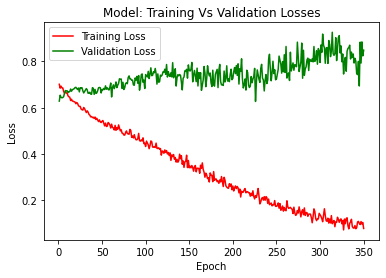

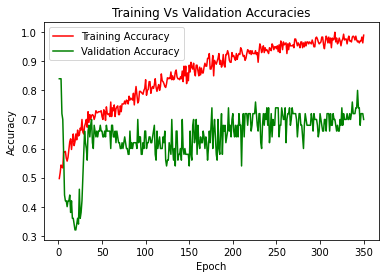

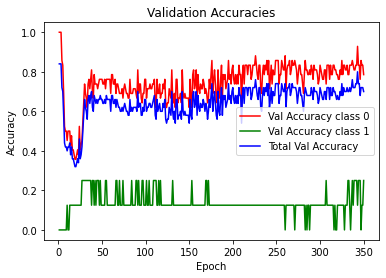

In [10]:
tipofunzione = 'train'
fold = 1
continue_learning = 'false'
tipoNormalizzazione_str = 'None'
loss = 'cross'
  
print('tipofunzione ' + tipofunzione + ' - ' + 'fold ' + str(fold) +  ' - ' + 'continue_learning ' + continue_learning + ' tipoNormalizzazione_str ' + tipoNormalizzazione_str)
  
if continue_learning == 'true':
  continue_learning = True
else:
  continue_learning = False
  
esclusi = ['115-116']
dfs = pd.read_excel('/content/drive/My Drive/CampusBioMedico/NewFold_10_Confronto.xlsx', sheet_name='Foglio1')
classes = ['0_cavo', '1_cavo']
basePath = 'VolumiDCE_EachLesion_Isotropic'
  
minDimLesion = 30
fattore = 0.1
epocheFineTuning = 100
learningRate = 0.00001
weightDecay = 0.0001
batchSize = 16
num_epoch = 350
ch = 8

test_set = dfs[dfs.FOLD == fold].ID.to_list()
valFold = dfs[dfs.FOLD == fold].Fold_to_use.values[0]
vali_set = dfs[dfs.FOLD == valFold].ID.to_list()
print('Test: fold ' + str(fold))
print(test_set)
print('Val: fold ' + str(valFold))
print(vali_set)
  
if len(list(set(test_set) & set(vali_set)))>0:
  print('errore!!!')
  
outputPath = '/content/drive/My Drive/CampusBioMedico/DCE_3DEachLesionIsotropic_withMask_lr1_' + loss +'_'+str(ch)+ '/Fold' + str(fold) +'/'
  
try:
  os.makedirs(outputPath)
except OSError:
  pass
    
with open(outputPath + 'InfoAddestramento.txt', "w") as file_object:
  file_object.write('batch_size: '+str(batchSize)+'\n')
  file_object.write('lr: '+str(learningRate)+'\n')
  file_object.write('decay: '+str(weightDecay)+'\n')
  file_object.write('minDimLesion: '+ str(minDimLesion)+'\n')
  file_object.write('fattore per il fine tuning sul val: '+ str(fattore)+'\n')
  file_object.write('epocheFineTuning: '+ str(epocheFineTuning)+'\n')
  file_object.write('tipoNormalizzazione: '+ tipoNormalizzazione_str +'\n')
  file_object.write('Info: Rete standard piccola si padding, , 2 linear \n')
  file_object.write('Range 01')
    
  
if tipofunzione == 'train':
  main_TRAIN(fold,continue_learning, tipoNormalizzazione_str, loss,
             basePath, classes, ch, learningRate, weightDecay, batchSize, num_epoch, 
             vali_set, test_set, esclusi, minDimLesion,
             outputPath)
  main_validation(fold,False, tipoNormalizzazione_str, loss,
                    basePath, classes, ch, learningRate, weightDecay, batchSize, epocheFineTuning, fattore, 
                    vali_set, test_set, esclusi, minDimLesion,
                    outputPath )
  
  main_final_restrain(fold,False, tipoNormalizzazione_str, loss,
                     basePath, classes, ch, learningRate, weightDecay, batchSize, 
                     vali_set, test_set, esclusi, minDimLesion,
                     outputPath)
  
elif tipofunzione == 'val':
  main_validation(fold,continue_learning, tipoNormalizzazione_str,  loss,
                  basePath, classes, ch, learningRate, weightDecay, batchSize, epocheFineTuning, fattore,
                  vali_set, test_set, esclusi, minDimLesion,
                  outputPath )
else:
  print('RETRAIN SELEZIONATO')
  main_final_restrain(fold,continue_learning, tipoNormalizzazione_str,  loss,
                     basePath, classes, ch, learningRate, weightDecay, batchSize, 
                     vali_set, test_set, esclusi, minDimLesion,
                     outputPath)  